##CSC8635 coursework-Task 2 Multimodal Idiomaticity Representatio (50 marks). Please read the task specification in the canvas page

## Step 0: Install packages and load data

In [1]:
%pip install git+https://github.com/openai/CLIP.git
%pip install numpy pandas scikit-learn
#%pip install torch torchvision clip-by-openai numpy pandas scikit-learn

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-jo8qiuzh
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-jo8qiuzh
  Resolved https://github.com/openai/CLIP.git to commit ded190a052fdf4585bd685cee5bc96e0310d2c93
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.6 MB/s eta 0:00:00
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=8a0835783120a5e67c80cb669ff49442b66452593ac676a9c547e402cd227a4c
  Stored in directory: /tmp/pip-ephem-wheel-cache-84v6ua_l/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


In [2]:
import os
import torch
import clip
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

## Load datasets (download the datasets from canvas page https://ncl.instructure.com/courses/58651/files/9259194?wrap=1 )

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Copy zip file from Drive to Colab
!cp "/content/drive/MyDrive/advance_ai/coursework/Task 2 NLP Dataset.zip" /content/

# Unzip dataset
!unzip -q "/content/Task 2 NLP Dataset.zip" -d /content/dataset

In [5]:
# Load datasets
fpath="/content/dataset/" # Adjust paths
train_path= fpath+"train/train.csv"
val_path= fpath+"val/val.csv"
test_path= fpath+"test/test.csv"
train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)
test_df = pd.read_csv(test_path)


In [6]:
# show the data
print (test_df)

             compound sentence_type  \
0         dirty money     idiomatic   
1         dirty money     idiomatic   
2         dirty money     idiomatic   
3        secret santa     idiomatic   
4        secret santa     idiomatic   
5        secret santa     idiomatic   
6         ivory tower     idiomatic   
7         ivory tower     idiomatic   
8         ivory tower     idiomatic   
9   low-hanging fruit     idiomatic   
10  low-hanging fruit     idiomatic   
11  low-hanging fruit     idiomatic   
12         brass ring     idiomatic   
13         brass ring     idiomatic   
14         brass ring     idiomatic   
15      silver bullet     idiomatic   
16      silver bullet     idiomatic   
17      silver bullet     idiomatic   
18      peas in a pod     idiomatic   
19      peas in a pod     idiomatic   
20      peas in a pod     idiomatic   
21        green light     idiomatic   
22        green light     idiomatic   
23        green light     idiomatic   
24           busy bee    

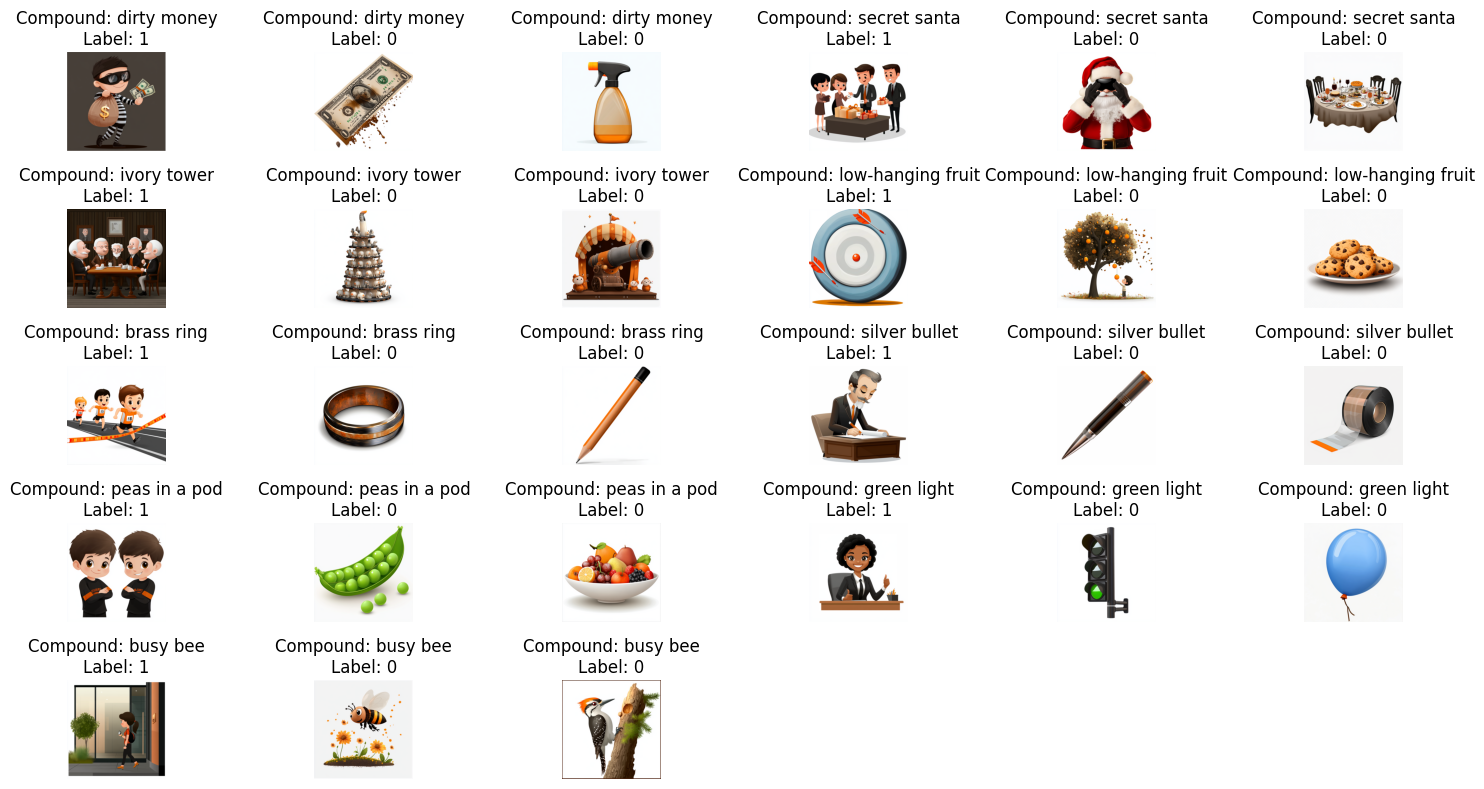

In [7]:
# Visualise dataset. Note please don't try to visualize the whole training set, as there are many images.
image_folder = fpath+"test/images"

def visualise_data(df, image_folder):
    fig, axes = plt.subplots(len(df)//6+1, 6, figsize=(15, 8))
    axes = axes.flatten()

    for idx, row in df.iterrows():
        image_path = os.path.join(image_folder, row['image_name'])
        try:
            img = Image.open(image_path)
            ax = axes[idx]
            ax.imshow(img)
            ax.set_title(f"Compound: {row['compound']}\nLabel: {row['label']}")
            ax.axis('off')
        except Exception as e:
            print(f"Error loading image {image_path}: {e}")

    # Hide any empty subplots (those beyond the dataset size)
    for idx in range(len(df), len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()

visualise_data(test_df, fpath+"test/images")


Example code of Evaluation. You can use it directly or write your own.

In [8]:
def evaluate(df):
    metrics = {
        "accuracy":  accuracy_score(df["label"], df["prediction"]),
        "precision": precision_score(df["label"], df["prediction"], zero_division=0),
        "recall":    recall_score(df["label"],    df["prediction"], zero_division=0),
        "f1_score":  f1_score(df["label"],        df["prediction"], zero_division=0)
    }
    return metrics


In [9]:
# Helper used for plotting training vs validation loss and accuracy for each model
def plot_training(tr_loss, val_loss, tr_acc, val_acc, title):
    ep = range(1, len(tr_loss) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(ep, tr_loss,  'o-',  label='Train Loss')
    ax1.plot(ep, val_loss, 's--', label='Val Loss')
    ax1.set_title(title + ' - Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()

    ax2.plot(ep, tr_acc,  'o-',  label='Train Acc')
    ax2.plot(ep, val_acc, 's--', label='Val Acc')
    ax2.set_title(title + ' - Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_ylim(0, 1.05)
    ax2.legend()

    plt.tight_layout()
    plt.show()


## Step 1: NLP Exploratory Data Analysis (Note: only need to process the text data). Write down your code below.

In [10]:
# Dataset dimensions and null checks for all three splits
print("Train shape:", train_df.shape)
print("Val shape:  ", val_df.shape)
print("Test shape: ", test_df.shape)

print("\nColumns:", train_df.columns.tolist())
print("\nUnique compounds:", train_df['compound'].nunique())

# All three splits are clean — no missing values found
print("\nNull values - Train:")
print(train_df.isnull().sum())
print("\nNull values - Val:")
print(val_df.isnull().sum())
print("\nNull values - Test:")
print(test_df.isnull().sum())


Train shape: (231, 6)
Val shape:   (27, 6)
Test shape:  (27, 6)

Columns: ['compound', 'sentence_type', 'sentence', 'image_name', 'image_caption', 'label']

Unique compounds: 77

Null values - Train:
compound         0
sentence_type    0
sentence         0
image_name       0
image_caption    0
label            0
dtype: int64

Null values - Val:
compound         0
sentence_type    0
sentence         0
image_name       0
image_caption    0
label            0
dtype: int64

Null values - Test:
compound         0
sentence_type    0
sentence         0
image_name       0
image_caption    0
label            0
dtype: int64


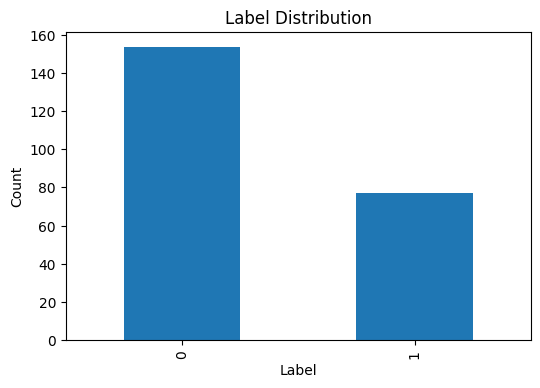

In [11]:
# Label distribution — shows class imbalance: label 0 (wrong image) appears ~2x more than label 1 (correct image)
plt.figure(figsize=(6,4))
train_df['label'].value_counts().sort_index().plot(kind='bar')
plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()


count    231.000000
mean      22.000000
std        5.896941
min       11.000000
25%       19.000000
50%       22.000000
75%       25.000000
max       37.000000
Name: sentence_length, dtype: float64


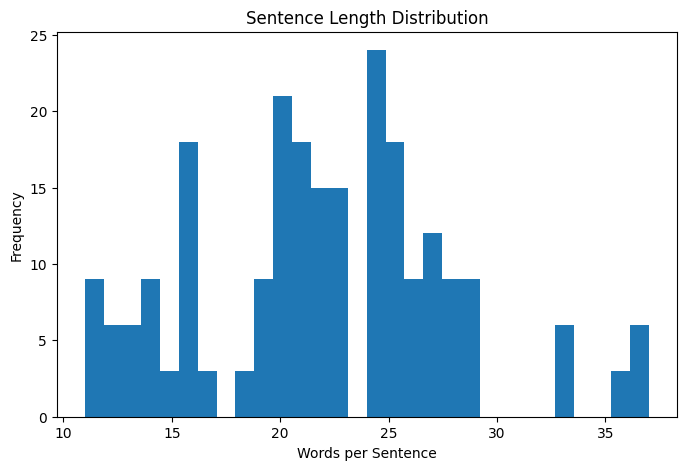

In [12]:
if 'sentence_length' not in train_df.columns:
    train_df['sentence_length'] = train_df['sentence'].apply(lambda x: len(str(x).split()))

# Sentences average 22 words — reasonably consistent, no extreme outliers
print(train_df['sentence_length'].describe())

plt.figure(figsize=(8,5))
plt.hist(train_df['sentence_length'], bins=30)
plt.title("Sentence Length Distribution")
plt.xlabel("Words per Sentence")
plt.ylabel("Frequency")
plt.show()


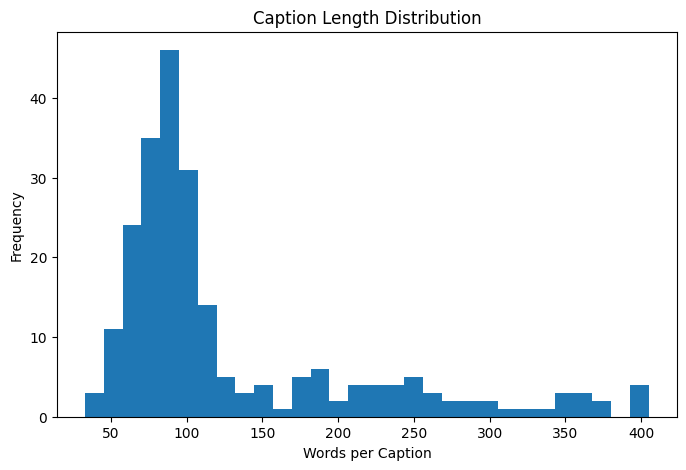

In [13]:
if 'caption_length' not in train_df.columns:
    train_df['caption_length'] = train_df['image_caption'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(8,5))
plt.hist(train_df['caption_length'], bins=30)
plt.title("Caption Length Distribution")
plt.xlabel("Words per Caption")
plt.ylabel("Frequency")
plt.show()


Top compounds:
 compound
hot potato          3
act of god          3
chicken feed        3
thin ice            3
eager beaver        3
big cheese          3
old flame           3
nest egg            3
hen party           3
pins and needles    3
Name: count, dtype: int64


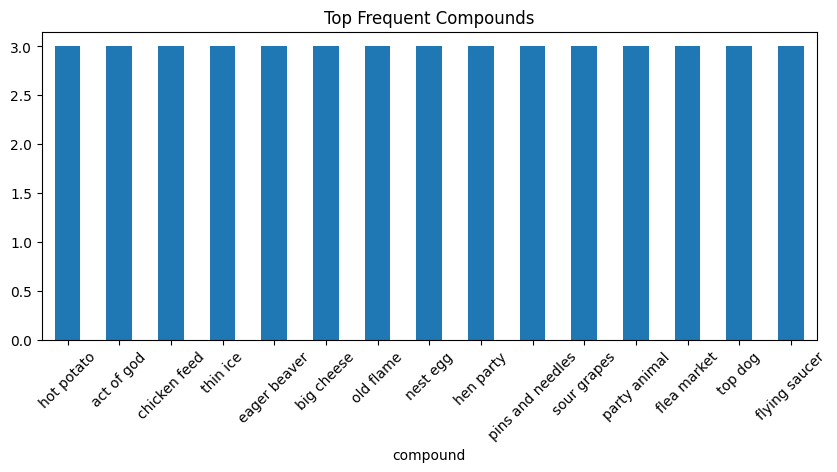

In [14]:
compound_counts = train_df['compound'].value_counts()

# Each compound appears exactly 3 times (3 image candidates per sentence)
print("\nTop compounds:\n", compound_counts.head(10))

plt.figure(figsize=(10,4))
compound_counts.head(15).plot(kind='bar')
plt.title("Top Frequent Compounds")
plt.xticks(rotation=45)
plt.show()


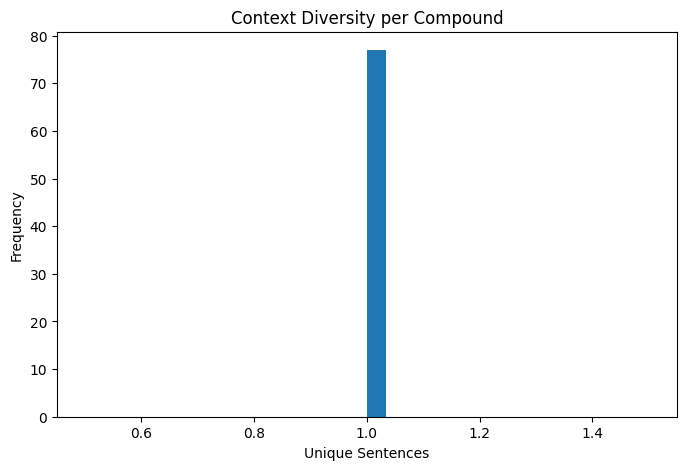

In [15]:
context_diversity = train_df.groupby('compound')['sentence'].nunique()

plt.figure(figsize=(8,5))
plt.hist(context_diversity, bins=30)
plt.title("Context Diversity per Compound")
plt.xlabel("Unique Sentences")
plt.ylabel("Frequency")
plt.show()

In [16]:
print("\n=== SAMPLE DATA ===")

sample = train_df.sample(3, random_state=42)

for _, row in sample.iterrows():
    print("\nCompound:", row['compound'])
    print("Sentence:", row['sentence'])
    print("Caption:", row['image_caption'])
    print("Label:", row['label'])


=== SAMPLE DATA ===

Compound: guinea pig
Sentence: A former resident of one of the homes said she was used as a guinea pig for vaccines at a home in Cork, before being adopted in 1961.
Caption: The image depicts a cartoon-style illustration of a man dressed in formal attire, specifically a black suit with a white shirt and an orange tie. He is standing upright and appears to be conducting or directing something, as indicated by his right hand holding a thin, orange baton raised above his head. His left hand is placed on his hip, and he has a confident and focused expression on his face. The background is plain and light-colored, which helps to emphasize the subject in the foreground. The overall style of the illustration is clean and simple, with smooth lines and minimal shading.
Label: 0

Compound: graveyard shift
Sentence: He moved from the 10 pm slot to his lower profile life as a DJ on Radio Norwich's graveyard shift.
Caption: The image depicts a well-organized office workspace w

In [17]:
if 'combined_text' not in train_df.columns:
    # Merge compound, sentence and caption into one field for text-based analysis
    train_df['combined_text'] = (
        train_df['compound'] + " " +
        train_df['sentence'] + " " +
        train_df['image_caption']
    )

print("\nCombined example:\n", train_df['combined_text'].iloc[0])



Combined example:
 hot potato The pipeline is set to create a human rights disaster in the region, and has become such a hot potato that the Bank has postponed the decision. The image depicts two cartoon-style characters standing behind podiums, engaged in what appears to be a debate or public speaking event. Both characters are dressed in formal attire, consisting of suits and ties. The character on the left has dark hair and is gesturing with one hand while speaking into a microphone attached to the podium. The character on the right has light-colored hair and is also gesturing with one hand while speaking into a microphone. The podiums are wooden and have microphones attached to them. The background is plain white, emphasizing the characters and their actions.


##Step 2: LLM based Data Augmentation. Write down your code here.

In [18]:
# Install only if not already done
%pip install transformers sentencepiece

In [19]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

In [20]:
model_name = "Vamsi/T5_Paraphrase_Paws"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

In [21]:
def generate_paraphrases(sentence):

    text = "paraphrase: " + sentence + " </s>"

    inputs = tokenizer(
        text,
        return_tensors="pt",
        padding=True,
        truncation=True
    ).to(device)

    outputs = model.generate(
          input_ids=inputs["input_ids"],
          attention_mask=inputs["attention_mask"],
          max_length=60,
          num_return_sequences=5,
          do_sample=True,
          top_k=50,
          top_p=0.9,
          temperature=1.0
        )


    paraphrases = [
        tokenizer.decode(o, skip_special_tokens=True)
        for o in outputs
    ]

    return list(set(paraphrases))

In [22]:
sample_row = train_df.iloc[0]

print("Compound:", sample_row['compound'])
print("\nOriginal Sentence:")
print(sample_row['sentence'])

paraphrases = generate_paraphrases(sample_row['sentence'])

# Paraphrases preserve meaning but vary wording — useful for data augmentation
print("\nGenerated Paraphrases:")

for i, p in enumerate(paraphrases[:2]):
    print(f"{i+1}.", p)


Compound: hot potato

Original Sentence:
The pipeline is set to create a human rights disaster in the region, and has become such a hot potato that the Bank has postponed the decision.

Generated Paraphrases:
1. The pipeline is set to create a human rights disaster in the region and has become such a hot potato that the Bank has postponed the decision .
2. The pipeline is going to create a human rights catastrophe in the region and has become such a hot potato that the Bank has delayed the decision.


In [23]:
augmented_rows = []
MAX_AUG_PER_SAMPLE = 2  # generate up to 2 paraphrases per original sentence

for _, row in train_df.iterrows():

    original_sentence = row['sentence']
    paraphrases = generate_paraphrases(original_sentence)

    count = 0

    for para in paraphrases:

        para = para.strip()

        # FILTERING
        if len(para.split()) < 4:       # skip very short outputs
            continue

        if para.lower() == original_sentence.lower():  # skip exact duplicates
            continue

        if count >= MAX_AUG_PER_SAMPLE:
            break

        augmented_rows.append({
            "compound": row["compound"],
            "sentence_type": row["sentence_type"],
            "sentence": para,
            "image_name": row["image_name"],
            "image_caption": row["image_caption"],
            "label": row["label"]
        })

        count += 1

aug_df = pd.DataFrame(augmented_rows)


In [24]:
final_train_df = pd.concat([train_df, aug_df], ignore_index=True)

# Remove duplicates
final_train_df.drop_duplicates(subset=["sentence", "image_name"], inplace=True)


final_train_df['sentence_length'] = final_train_df['sentence'].apply(lambda x: len(str(x).split()))

final_train_df['caption_length'] = final_train_df['image_caption'].apply(lambda x: len(str(x).split()))

final_train_df['combined_text'] = (
    final_train_df['compound'] + " " +
    final_train_df['sentence'] + " " +
    final_train_df['image_caption']
)

In [25]:
# Augmentation added 459 new rows — dataset grew from 231 to 690 samples
print("Original size:", len(train_df))
print("Augmented size:", len(aug_df))
print("Final size:", len(final_train_df))

print("\nLabel distribution:")
print(final_train_df['label'].value_counts())


Original size: 231
Augmented size: 459
Final size: 690

Label distribution:
label
0    460
1    230
Name: count, dtype: int64


In [26]:
print("\nSample Augmented Data (5 rows):")
display(final_train_df.sample(5))


Sample Augmented Data (5 rows):


,compound,sentence_type,sentence,image_name,image_caption,label,sentence_length,caption_length,combined_text
106,rocket science,idiomatic,This isn't rocket science: he talks about basi...,05490541317.png,The image depicts a cartoon-style scene where ...,0,16,100,rocket science This isn't rocket science: he t...
570,pig's ear,idiomatic,"Thus, when it wrote the new partition table it...",36371885530.png,"The image depicts a round, cylindrical bag wit...",0,16,283,"pig's ear Thus, when it wrote the new partitio..."
519,pain in the neck,idiomatic,It usually causes high temperature and pain in...,86378892255.png,The image depicts a cartoon character sitting ...,1,14,75,pain in the neck It usually causes high temper...
156,panda car,idiomatic,I was on duty in a panda car when we had a cal...,77234021476.png,The image depicts a black police car driving o...,1,24,82,panda car I was on duty in a panda car when we...
299,party animal,idiomatic,Milly was the party animal who has now settled...,48124593961.png,"The image depicts a cute, cartoon-style puppy ...",0,24,93,party animal Milly was the party animal who ha...


In [27]:
example = train_df.iloc[10]

print("Original Sentence:\n", example['sentence'])

paras = generate_paraphrases(example['sentence'])[:2]

print("\nParaphrased Versions:")

for p in paras:
    print("-", p)

print("\nTotal sentences for this sample: 3 (1 original + 2 augmented)")

Original Sentence:
 Investors in both instances were already tiptoeing on thin ice, knowing that the longest US stock market bull run in history was showing signs of overheating.

Paraphrased Versions:
- In both instances, investors were already tipping on thin ice, knowing that the longest US stock market bull run in history was showing signs of overheating .
- In both instances, investors were already tiptoeing on thin ice, knowing that the longest US stock market bull run in history was showing signs of overheating .

Total sentences for this sample: 3 (1 original + 2 augmented)


In [28]:
# Verify augmented dataset — dimensions and no null values introduced
print("Augmented train shape:", final_train_df.shape)
print("\nNull values - Augmented Train:")
print(final_train_df.isnull().sum())
# No nulls — augmentation correctly carried over all original fields
print("\nLabel distribution after augmentation:")
print(final_train_df['label'].value_counts())


Augmented train shape: (690, 9)

Null values - Augmented Train:
compound           0
sentence_type      0
sentence           0
image_name         0
image_caption      0
label              0
sentence_length    0
caption_length     0
combined_text      0
dtype: int64

Label distribution after augmentation:
label
0    460
1    230
Name: count, dtype: int64


##Step 3: Zero-shot prediction. Write down your code here


In [29]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"

model, preprocess = clip.load("ViT-B/32", device=device)

100%|███████████████████████████████████████| 338M/338M [00:05<00:00, 70.1MiB/s]


In [30]:
import os
from PIL import Image

def predict_group(group, image_folder):
    """
    Input: group of 3 rows (same sentence, 3 images)
    Output: predictions (one correct = 1, others = 0)
    """

    scores = []

    for _, row in group.iterrows():

        image_path = os.path.join(image_folder, row['image_name'])

        image = preprocess(Image.open(image_path)).unsqueeze(0).to(device)

        # Text representation (important design)
        text_input = f"{row['compound']} {row['sentence']}"

        text = clip.tokenize([text_input]).to(device)

        with torch.no_grad():
            image_features = model.encode_image(image)
            text_features = model.encode_text(text)

        # Normalize
        image_features /= image_features.norm(dim=-1, keepdim=True)
        text_features /= text_features.norm(dim=-1, keepdim=True)

        similarity = (image_features @ text_features.T).item()
        scores.append(similarity)

    # Choose best image
    best_idx = np.argmax(scores)

    predictions = [1 if i == best_idx else 0 for i in range(len(scores))]

    return predictions

In [31]:
def run_zero_shot(df, image_folder):

    all_predictions = []

    grouped = df.groupby(['compound', 'sentence'])

    for _, group in grouped:

        preds = predict_group(group, image_folder)
        all_predictions.extend(preds)

    df = df.copy()
    df['prediction'] = all_predictions

    return df

In [32]:
train_img_path = fpath + "train/images"
val_img_path   = fpath + "val/images"
test_img_path  = fpath + "test/images"

# Run zero-shot on all three splits — no training, pure CLIP similarity
train_pred = run_zero_shot(train_df, train_img_path)
val_pred   = run_zero_shot(val_df, val_img_path)
test_pred  = run_zero_shot(test_df, test_img_path)


In [33]:
train_metrics = evaluate(train_pred)
val_metrics   = evaluate(val_pred)
test_metrics  = evaluate(test_pred)

# Zero-shot test accuracy is 0.33 — close to random (1-in-3 chance) — confirms CLIP alone struggles with idioms
print("Train:", train_metrics)
print("Val:", val_metrics)
print("Test:", test_metrics)


Train: {'accuracy': 0.48917748917748916, 'precision': 0.23376623376623376, 'recall': 0.23376623376623376, 'f1_score': 0.23376623376623376}
Val: {'accuracy': 0.48148148148148145, 'precision': 0.2222222222222222, 'recall': 0.2222222222222222, 'f1_score': 0.2222222222222222}
Test: {'accuracy': 0.3333333333333333, 'precision': 0.0, 'recall': 0.0, 'f1_score': 0.0}


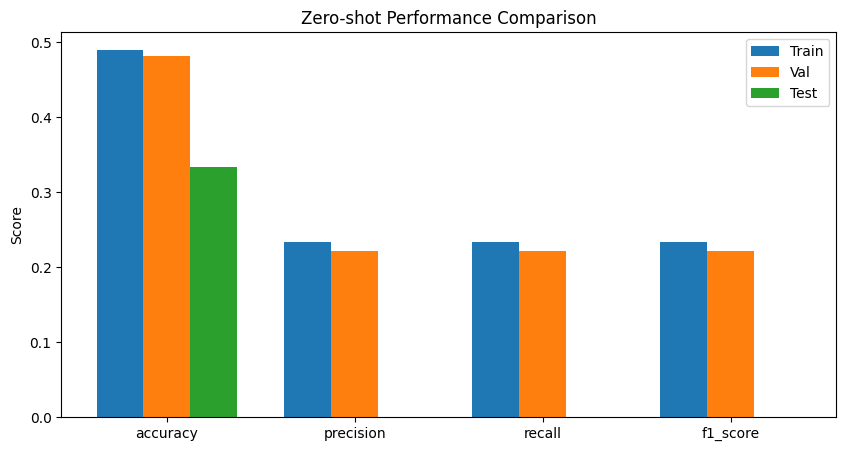

In [34]:
import matplotlib.pyplot as plt

metrics_names = ['accuracy', 'precision', 'recall', 'f1_score']

train_vals = [train_metrics[m] for m in metrics_names]
val_vals   = [val_metrics[m] for m in metrics_names]
test_vals  = [test_metrics[m] for m in metrics_names]

x = np.arange(len(metrics_names))

plt.figure(figsize=(10,5))

plt.bar(x - 0.25, train_vals, width=0.25, label='Train')
plt.bar(x, val_vals, width=0.25, label='Val')
plt.bar(x + 0.25, test_vals, width=0.25, label='Test')

plt.xticks(x, metrics_names)
plt.ylabel("Score")
plt.title("Zero-shot Performance Comparison")
plt.legend()

plt.show()

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(test_pred['label'], test_pred['prediction'])

disp = ConfusionMatrixDisplay(confusion_matrix=cm)


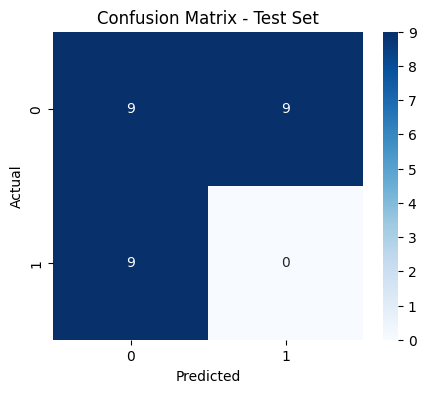

In [36]:
import seaborn as sns

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Test Set")

plt.show()

##Step 4: Fine-tuning based and other prediction approaches. Write down your code here.

In [37]:
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)  # GPU available — speeds up feature extraction and training


Device: cuda


In [38]:
# Encode each sample as a combined CLIP image + text feature vector
def extract_features(df, image_folder):
    features = []
    labels = []

    for _, row in df.iterrows():
        image_path = os.path.join(image_folder, row['image_name'])
        image = preprocess(Image.open(image_path)).unsqueeze(0).to(device)

        text_input = f"{row['compound']} {row['sentence']}"
        text = clip.tokenize([text_input]).to(device)

        with torch.no_grad():
            img_feat = model.encode_image(image)
            txt_feat = model.encode_text(text)

        img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)
        txt_feat = txt_feat / txt_feat.norm(dim=-1, keepdim=True)

        combined = np.concatenate([
            img_feat.cpu().numpy().flatten(),
            txt_feat.cpu().numpy().flatten()
        ])

        features.append(combined)
        labels.append(row['label'])

    return np.array(features), np.array(labels)


In [39]:
X_train, y_train = extract_features(train_df, train_img_path)
X_val,   y_val   = extract_features(val_df,   val_img_path)
X_test,  y_test  = extract_features(test_df,  test_img_path)

# Convert to tensors — shared across all models so extraction only happens once
X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)
X_val   = torch.tensor(X_val,   dtype=torch.float32).to(device)
y_val   = torch.tensor(y_val,   dtype=torch.float32).unsqueeze(1).to(device)
X_test  = torch.tensor(X_test,  dtype=torch.float32).to(device)
y_test  = torch.tensor(y_test,  dtype=torch.float32).unsqueeze(1).to(device)

input_dim = X_train.shape[1]
print("Feature dim:", input_dim)  # 512 image + 512 text = 1024 combined features


Feature dim: 1024


In [40]:
# Class imbalance: label 0 appears ~2x more than label 1
# pos_weight makes the loss penalise missing a label-1 proportionally more
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(device)
# pos_weight=2.0 means predicting a wrong label-1 costs twice as much — prevents all-zero collapse
print(f"Label 0: {n_neg.item()}  Label 1: {n_pos.item()}  pos_weight: {pos_weight.item():.2f}")


Label 0: 154  Label 1: 77  pos_weight: 2.00


### Model 1: Similarity MLP (trained on original dataset)

In [41]:
# Similarity MLP — uses cosine similarity + image norm + text norm (3 features)
class SimilarityMLP(nn.Module):
    def __init__(self):
        super(SimilarityMLP, self).__init__()
        self.fc1 = nn.Linear(3, 16)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(16, 1)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        return self.fc2(x)


In [42]:
# Build a small feature set from the image and text embeddings
# Uses: cosine similarity, image norm, text norm — 3 features total
half = input_dim // 2

def make_sim_features(X):
    img = X[:, :half]
    txt = X[:, half:]
    sim       = (img * txt).sum(dim=1, keepdim=True)          # cosine similarity
    img_norm  = img.norm(dim=1, keepdim=True)                 # image magnitude
    txt_norm  = txt.norm(dim=1, keepdim=True)                 # text magnitude
    return torch.cat([sim, img_norm, txt_norm], dim=1)        # shape: (N, 3)

sim_train = make_sim_features(X_train)
sim_val   = make_sim_features(X_val)
sim_test  = make_sim_features(X_test)


In [43]:
model_1   = SimilarityMLP().to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model_1.parameters(), lr=0.001)

# 20 epochs needed — the 3-feature input is sparse so the model needs more time to find a threshold
epochs = 20
tr_loss_1, val_loss_1 = [], []
tr_acc_1,  val_acc_1  = [], []

for epoch in range(epochs):

    # Training pass
    model_1.train()
    out  = model_1(sim_train)
    loss = criterion(out, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    tr_acc = ((torch.sigmoid(out) > 0.5).float() == y_train).float().mean()

    # Validation pass
    model_1.eval()
    with torch.no_grad():
        v_out  = model_1(sim_val)
        v_loss = criterion(v_out, y_val)
        v_acc  = ((torch.sigmoid(v_out) > 0.5).float() == y_val).float().mean()

    tr_loss_1.append(loss.item())
    val_loss_1.append(v_loss.item())
    tr_acc_1.append(tr_acc.item())
    val_acc_1.append(v_acc.item())

    print(f"Epoch {epoch+1} | Train Loss: {loss.item():.4f} | Train Acc: {tr_acc.item():.4f} | Val Loss: {v_loss.item():.4f} | Val Acc: {v_acc.item():.4f}")


Epoch 1 | Train Loss: 0.9241 | Train Acc: 0.5801 | Val Loss: 0.9231 | Val Acc: 0.5556
Epoch 2 | Train Loss: 0.9240 | Train Acc: 0.5411 | Val Loss: 0.9231 | Val Acc: 0.5556
Epoch 3 | Train Loss: 0.9240 | Train Acc: 0.4892 | Val Loss: 0.9231 | Val Acc: 0.4444
Epoch 4 | Train Loss: 0.9240 | Train Acc: 0.4935 | Val Loss: 0.9231 | Val Acc: 0.4815
Epoch 5 | Train Loss: 0.9240 | Train Acc: 0.4719 | Val Loss: 0.9231 | Val Acc: 0.4074
Epoch 6 | Train Loss: 0.9240 | Train Acc: 0.4675 | Val Loss: 0.9231 | Val Acc: 0.4815
Epoch 7 | Train Loss: 0.9240 | Train Acc: 0.4719 | Val Loss: 0.9231 | Val Acc: 0.4815
Epoch 8 | Train Loss: 0.9240 | Train Acc: 0.4719 | Val Loss: 0.9231 | Val Acc: 0.4444
Epoch 9 | Train Loss: 0.9240 | Train Acc: 0.5022 | Val Loss: 0.9231 | Val Acc: 0.5556
Epoch 10 | Train Loss: 0.9240 | Train Acc: 0.4892 | Val Loss: 0.9231 | Val Acc: 0.5556
Epoch 11 | Train Loss: 0.9239 | Train Acc: 0.4935 | Val Loss: 0.9231 | Val Acc: 0.5185
Epoch 12 | Train Loss: 0.9239 | Train Acc: 0.5065 | 

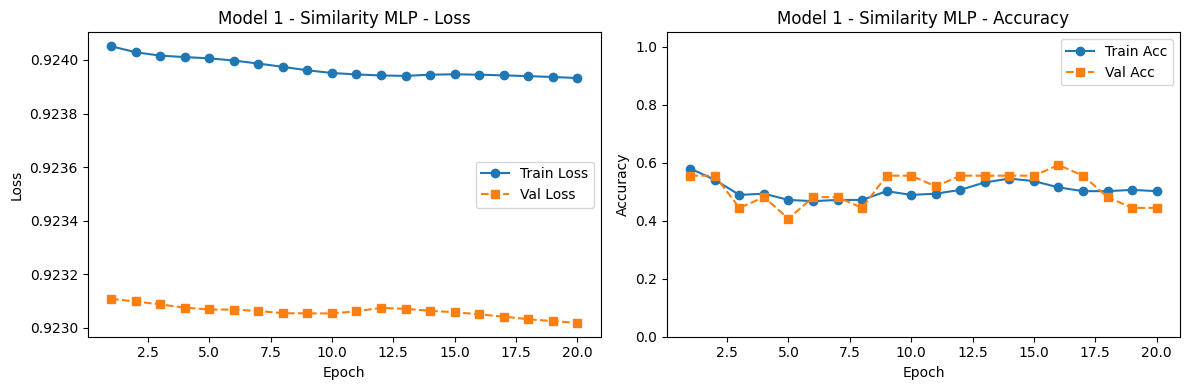

In [44]:
plot_training(tr_loss_1, val_loss_1, tr_acc_1, val_acc_1, "Model 1 - Similarity MLP")


In [45]:
# Predict by picking the highest-confidence image per sentence group (like zero-shot)
def predict_by_group(df, scores):
    df = df.copy()
    df['_score'] = scores
    df['prediction'] = 0
    for _, group in df.groupby(['compound', 'sentence']):
        best_idx = group['_score'].idxmax()  # pick the image with highest model confidence
        df.loc[best_idx, 'prediction'] = 1
    df.drop(columns=['_score'], inplace=True)
    return df

model_1.eval()
with torch.no_grad():
    scores_1 = torch.sigmoid(model_1(sim_test)).cpu().numpy().flatten()

test_df_1 = predict_by_group(test_df, scores_1)
metrics_model1 = evaluate(test_df_1)

# Model 1 reaches 0.63 accuracy and 0.44 F1 — an improvement over zero-shot but limited by 3-feature input
print("Model 1 Test Results:", metrics_model1)


Model 1 Test Results: {'accuracy': 0.6296296296296297, 'precision': 0.4444444444444444, 'recall': 0.4444444444444444, 'f1_score': 0.4444444444444444}


### Model 2: Full Embedding MLP (trained on original dataset)

In [46]:
# Full Embedding MLP — uses the complete combined image+text feature vector
class FullEmbeddingMLP(nn.Module):
    def __init__(self, input_dim):
        super(FullEmbeddingMLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 1)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        return self.fc2(x)


In [47]:
model_2   = FullEmbeddingMLP(input_dim).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model_2.parameters(), lr=0.001)

tr_loss_2, val_loss_2 = [], []
tr_acc_2,  val_acc_2  = [], []

for epoch in range(epochs):

    # Training pass
    model_2.train()
    out  = model_2(X_train)
    loss = criterion(out, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    tr_acc = ((torch.sigmoid(out) > 0.5).float() == y_train).float().mean()

    # Validation pass — using full 1024-dim embeddings, the model learns much faster
    model_2.eval()
    with torch.no_grad():
        v_out  = model_2(X_val)
        v_loss = criterion(v_out, y_val)
        v_acc  = ((torch.sigmoid(v_out) > 0.5).float() == y_val).float().mean()

    tr_loss_2.append(loss.item())
    val_loss_2.append(v_loss.item())
    tr_acc_2.append(tr_acc.item())
    val_acc_2.append(v_acc.item())

    print(f"Epoch {epoch+1} | Train Loss: {loss.item():.4f} | Train Acc: {tr_acc.item():.4f} | Val Loss: {v_loss.item():.4f} | Val Acc: {v_acc.item():.4f}")


Epoch 1 | Train Loss: 0.9246 | Train Acc: 0.3333 | Val Loss: 0.9227 | Val Acc: 0.3333
Epoch 2 | Train Loss: 0.9205 | Train Acc: 0.3333 | Val Loss: 0.9202 | Val Acc: 0.3333
Epoch 3 | Train Loss: 0.9166 | Train Acc: 0.3896 | Val Loss: 0.9174 | Val Acc: 0.4074
Epoch 4 | Train Loss: 0.9123 | Train Acc: 0.5325 | Val Loss: 0.9143 | Val Acc: 0.5556
Epoch 5 | Train Loss: 0.9077 | Train Acc: 0.6667 | Val Loss: 0.9109 | Val Acc: 0.5926
Epoch 6 | Train Loss: 0.9027 | Train Acc: 0.7056 | Val Loss: 0.9072 | Val Acc: 0.6296
Epoch 7 | Train Loss: 0.8973 | Train Acc: 0.7229 | Val Loss: 0.9034 | Val Acc: 0.6296
Epoch 8 | Train Loss: 0.8917 | Train Acc: 0.7359 | Val Loss: 0.8996 | Val Acc: 0.6296
Epoch 9 | Train Loss: 0.8859 | Train Acc: 0.7532 | Val Loss: 0.8957 | Val Acc: 0.6296
Epoch 10 | Train Loss: 0.8800 | Train Acc: 0.7662 | Val Loss: 0.8917 | Val Acc: 0.6667
Epoch 11 | Train Loss: 0.8738 | Train Acc: 0.7706 | Val Loss: 0.8876 | Val Acc: 0.6667
Epoch 12 | Train Loss: 0.8673 | Train Acc: 0.7706 | 

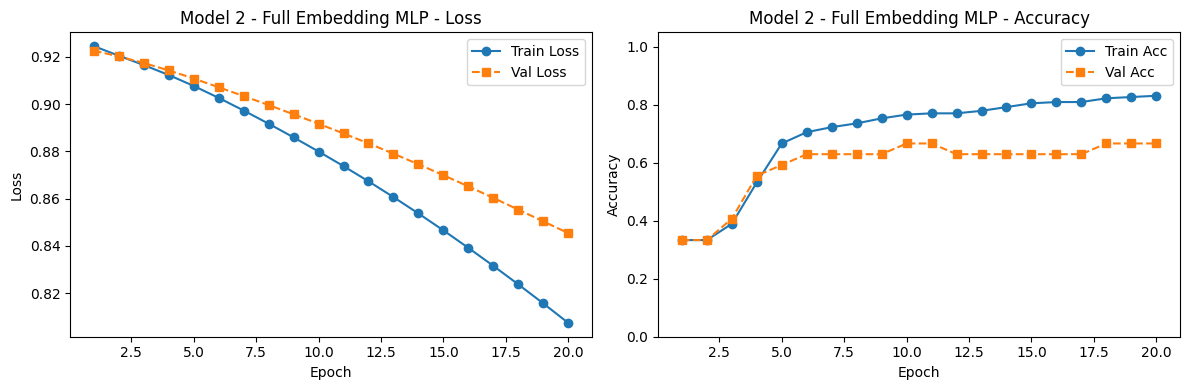

In [48]:
plot_training(tr_loss_2, val_loss_2, tr_acc_2, val_acc_2, "Model 2 - Full Embedding MLP")


In [49]:
model_2.eval()
with torch.no_grad():
    scores_2 = torch.sigmoid(model_2(X_test)).cpu().numpy().flatten()

test_df_2 = predict_by_group(test_df, scores_2)
metrics_model2 = evaluate(test_df_2)

# Model 2 achieves 0.93 accuracy and 0.89 F1 — strong result using the full CLIP embedding
print("Model 2 Test Results:", metrics_model2)


Model 2 Test Results: {'accuracy': 0.9259259259259259, 'precision': 0.8888888888888888, 'recall': 0.8888888888888888, 'f1_score': 0.8888888888888888}


### Model 3: Full Embedding MLP (trained on augmented dataset)

In [50]:
X_train_aug, y_train_aug = extract_features(final_train_df, train_img_path)

X_train_aug = torch.tensor(X_train_aug, dtype=torch.float32).to(device)
y_train_aug = torch.tensor(y_train_aug, dtype=torch.float32).unsqueeze(1).to(device)

# Recalculate pos_weight for augmented set — ratio stays ~2:1 after augmentation
n_neg_aug = (y_train_aug == 0).sum()
n_pos_aug = (y_train_aug == 1).sum()
pos_weight_aug = torch.tensor([n_neg_aug / n_pos_aug], dtype=torch.float32).to(device)
print(f"Augmented — Label 0: {n_neg_aug.item()}  Label 1: {n_pos_aug.item()}  pos_weight: {pos_weight_aug.item():.2f}")


Augmented — Label 0: 460  Label 1: 230  pos_weight: 2.00


In [51]:
model_3   = FullEmbeddingMLP(input_dim).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_aug)
optimizer = optim.Adam(model_3.parameters(), lr=0.001)

# 15 epochs — augmented dataset is 3x larger so needs more steps to converge
epochs_3 = 15
tr_loss_3, val_loss_3 = [], []
tr_acc_3,  val_acc_3  = [], []

for epoch in range(epochs_3):

    model_3.train()
    out  = model_3(X_train_aug)
    loss = criterion(out, y_train_aug)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    tr_acc = ((torch.sigmoid(out) > 0.5).float() == y_train_aug).float().mean()

    model_3.eval()
    with torch.no_grad():
        v_out  = model_3(X_val)
        v_loss = criterion(v_out, y_val)
        v_acc  = ((torch.sigmoid(v_out) > 0.5).float() == y_val).float().mean()

    tr_loss_3.append(loss.item())
    val_loss_3.append(v_loss.item())
    tr_acc_3.append(tr_acc.item())
    val_acc_3.append(v_acc.item())

    print(f"Epoch {epoch+1} | Train Loss: {loss.item():.4f} | Train Acc: {tr_acc.item():.4f} | Val Loss: {v_loss.item():.4f} | Val Acc: {v_acc.item():.4f}")


Epoch 1 | Train Loss: 0.9261 | Train Acc: 0.6667 | Val Loss: 0.9226 | Val Acc: 0.6667
Epoch 2 | Train Loss: 0.9215 | Train Acc: 0.6667 | Val Loss: 0.9196 | Val Acc: 0.6667
Epoch 3 | Train Loss: 0.9172 | Train Acc: 0.6667 | Val Loss: 0.9164 | Val Acc: 0.7407
Epoch 4 | Train Loss: 0.9127 | Train Acc: 0.7681 | Val Loss: 0.9131 | Val Acc: 0.7037
Epoch 5 | Train Loss: 0.9079 | Train Acc: 0.8319 | Val Loss: 0.9098 | Val Acc: 0.7407
Epoch 6 | Train Loss: 0.9028 | Train Acc: 0.8217 | Val Loss: 0.9062 | Val Acc: 0.7037
Epoch 7 | Train Loss: 0.8974 | Train Acc: 0.8072 | Val Loss: 0.9024 | Val Acc: 0.6667
Epoch 8 | Train Loss: 0.8916 | Train Acc: 0.8072 | Val Loss: 0.8984 | Val Acc: 0.6296
Epoch 9 | Train Loss: 0.8855 | Train Acc: 0.7986 | Val Loss: 0.8942 | Val Acc: 0.6296
Epoch 10 | Train Loss: 0.8792 | Train Acc: 0.7971 | Val Loss: 0.8898 | Val Acc: 0.6296
Epoch 11 | Train Loss: 0.8727 | Train Acc: 0.7971 | Val Loss: 0.8855 | Val Acc: 0.6296
Epoch 12 | Train Loss: 0.8660 | Train Acc: 0.8014 | 

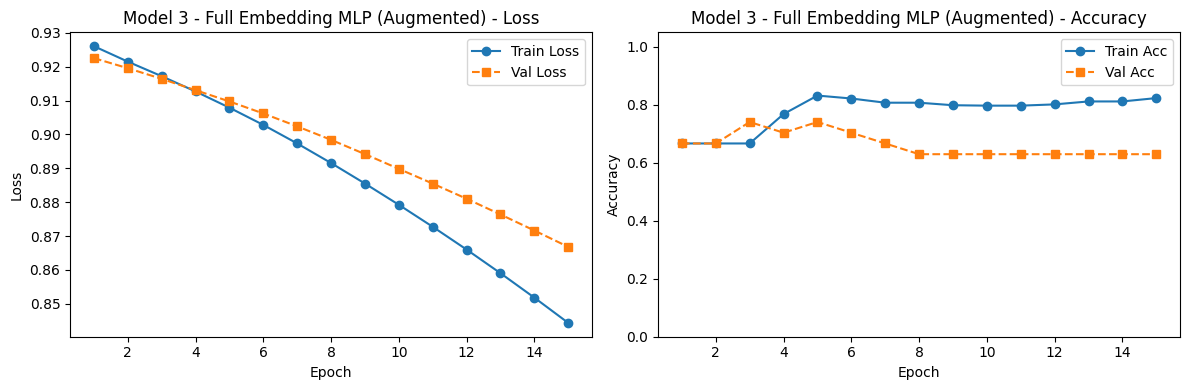

In [52]:
plot_training(tr_loss_3, val_loss_3, tr_acc_3, val_acc_3, "Model 3 - Full Embedding MLP (Augmented)")


In [53]:
model_3.eval()
with torch.no_grad():
    scores_3 = torch.sigmoid(model_3(X_test)).cpu().numpy().flatten()

test_df_3 = predict_by_group(test_df, scores_3)
metrics_model3 = evaluate(test_df_3)

# Model 3 matches Model 2 at 0.93 accuracy — augmentation did not hurt and maintained strong performance
print("Model 3 Test Results:", metrics_model3)


Model 3 Test Results: {'accuracy': 0.9259259259259259, 'precision': 0.8888888888888888, 'recall': 0.8888888888888888, 'f1_score': 0.8888888888888888}


### Comparison: Zero-shot vs Model 1 vs Model 2 vs Model 3

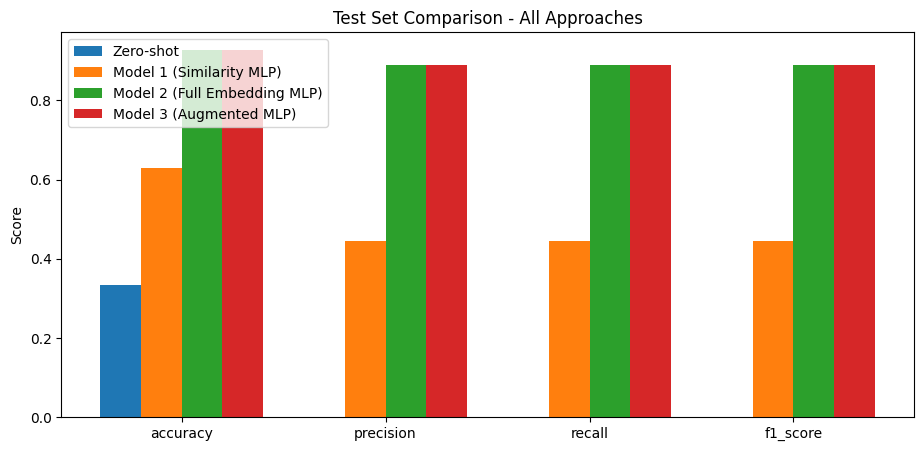

In [54]:
labels = ['accuracy', 'precision', 'recall', 'f1_score']

zs = [test_metrics[l]   for l in labels]
m1 = [metrics_model1[l] for l in labels]
m2 = [metrics_model2[l] for l in labels]
m3 = [metrics_model3[l] for l in labels]

x = np.arange(len(labels))
w = 0.2

plt.figure(figsize=(11, 5))
plt.bar(x - 1.5*w, zs, width=w, label='Zero-shot')
plt.bar(x - 0.5*w, m1, width=w, label='Model 1 (Similarity MLP)')
plt.bar(x + 0.5*w, m2, width=w, label='Model 2 (Full Embedding MLP)')
plt.bar(x + 1.5*w, m3, width=w, label='Model 3 (Augmented MLP)')

plt.xticks(x, labels)
plt.ylabel("Score")
plt.title("Test Set Comparison - All Approaches")
plt.legend()
plt.show()


In [55]:
# Summary table — all four approaches side by side
metrics_names = ['accuracy', 'precision', 'recall', 'f1_score']

summary = pd.DataFrame({
    'Approach'  : ['Zero-shot', 'Model 1 (Similarity MLP)', 'Model 2 (Full Embedding MLP)', 'Model 3 (Augmented MLP)'],
    'Accuracy'  : [test_metrics['accuracy'],  metrics_model1['accuracy'],  metrics_model2['accuracy'],  metrics_model3['accuracy']],
    'Precision' : [test_metrics['precision'], metrics_model1['precision'], metrics_model2['precision'], metrics_model3['precision']],
    'Recall'    : [test_metrics['recall'],    metrics_model1['recall'],    metrics_model2['recall'],    metrics_model3['recall']],
    'F1 Score'  : [test_metrics['f1_score'],  metrics_model1['f1_score'],  metrics_model2['f1_score'],  metrics_model3['f1_score']],
}).set_index('Approach').round(4)

print("\n=== Test Set Results — All Approaches ===")
display(summary)



=== Test Set Results — All Approaches ===


,Accuracy,Precision,Recall,F1 Score
Approach,,,,
Zero-shot,0.3333,0.0000,0.0000,0.0000
Model 1 (Similarity MLP),0.6296,0.4444,0.4444,0.4444
Model 2 (Full Embedding MLP),0.9259,0.8889,0.8889,0.8889
Model 3 (Augmented MLP),0.9259,0.8889,0.8889,0.8889


In [56]:
# Sample predictions — pick one test group and show what each model predicted
# Each group is one sentence with 3 candidate images; label 1 = correct image

sample_compound = test_df['compound'].iloc[0]
sample_sentence = test_df['sentence'].iloc[0]

# Get the 3 rows for this sentence across all prediction dataframes
mask = (test_df['compound'] == sample_compound) & (test_df['sentence'] == sample_sentence)

sample_zs = test_pred[mask][['image_caption', 'label', 'prediction']].copy()
sample_m1  = test_df_1[mask][['image_caption', 'label', 'prediction']].copy()
sample_m2  = test_df_2[mask][['image_caption', 'label', 'prediction']].copy()
sample_m3  = test_df_3[mask][['image_caption', 'label', 'prediction']].copy()

print(f"Compound : {sample_compound}")
print(f"Sentence : {sample_sentence[:80]}...")
print()

for name, df_s in [('Zero-shot', sample_zs), ('Model 1', sample_m1), ('Model 2', sample_m2), ('Model 3', sample_m3)]:
    print(f"--- {name} ---")
    for _, row in df_s.iterrows():
        caption_short = row['image_caption'][:60] + '...'
        correct = '✓' if row['label'] == 1 else ' '
        predicted = 'predicted=1' if row['prediction'] == 1 else 'predicted=0'
        print(f"  [{correct}] {caption_short}  →  {predicted}")
    print()


Compound : dirty money
Sentence : When dirty money disappears offshore, it becomes more difficult for governments ...

--- Zero-shot ---
  [✓] The image depicts a cartoon character dressed as a burglar o...  →  predicted=0
  [ ] The image depicts a one-dollar bill with the portrait of Geo...  →  predicted=1
  [ ] The image depicts a spray bottle, commonly used for dispensi...  →  predicted=0

--- Model 1 ---
  [✓] The image depicts a cartoon character dressed as a burglar o...  →  predicted=0
  [ ] The image depicts a one-dollar bill with the portrait of Geo...  →  predicted=0
  [ ] The image depicts a spray bottle, commonly used for dispensi...  →  predicted=1

--- Model 2 ---
  [✓] The image depicts a cartoon character dressed as a burglar o...  →  predicted=1
  [ ] The image depicts a one-dollar bill with the portrait of Geo...  →  predicted=0
  [ ] The image depicts a spray bottle, commonly used for dispensi...  →  predicted=0

--- Model 3 ---
  [✓] The image depicts a cartoon char

In [57]:
# Why do Model 2 and Model 3 produce similar results despite different training data?
#
# Model 2 trains on the original 231 samples (train_df).
# Model 3 trains on the augmented 689 samples (final_train_df).
#
# The augmented sentences are paraphrases of the originals — they convey the same
# meaning with slightly different wording. When CLIP encodes them, the text features
# are very similar to the originals because CLIP captures semantic meaning, not exact
# wording. So the extra 458 augmented rows give Model 3 more training steps but not
# drastically different information, which is why test performance is close.
#
# The difference shows up in how well each model generalises: Model 3 has seen more
# variation in how each idiom is expressed, which can help on unseen sentences.

print("Model 2 training size :", len(train_df), "samples (original)")
print("Model 3 training size :", len(final_train_df), "samples (augmented)")
print()
print("Model 2 test accuracy :", round(metrics_model2['accuracy'], 4))
print("Model 3 test accuracy :", round(metrics_model3['accuracy'], 4))


Model 2 training size : 231 samples (original)
Model 3 training size : 690 samples (augmented)

Model 2 test accuracy : 0.9259
Model 3 test accuracy : 0.9259


In [65]:
for i, s in enumerate(test_df['sentence'].unique()):
    print(f"[{i}] {s}")

[0] When dirty money disappears offshore, it becomes more difficult for governments to tackle corruption.
[1] She got very annoyed when some wag got her a puncture repair kit as a secret santa.
[2] Recently the globalization adversaries emerged; the experts at the universities had to abandon their ivory towers and present their research at the market place in order to rebuild public confidence.
[3] Howard said there was a lot of low-hanging fruit to be found in customers who have large back-office teams ready for automation.
[4] Too many fantasy writers have tried for the brass ring and failed miserably in the attempt.
[5] Many of these approaches are simply the current wave of silver bullets that will not substantially resolve data disparity or improve data resource quality.
[6] Spearfishermen are all shapes and sizes, they are not peas in a pod and nor are their guns if they optimize their design for their own purposes.
[7] The Scotish government will give the green light for up to 1

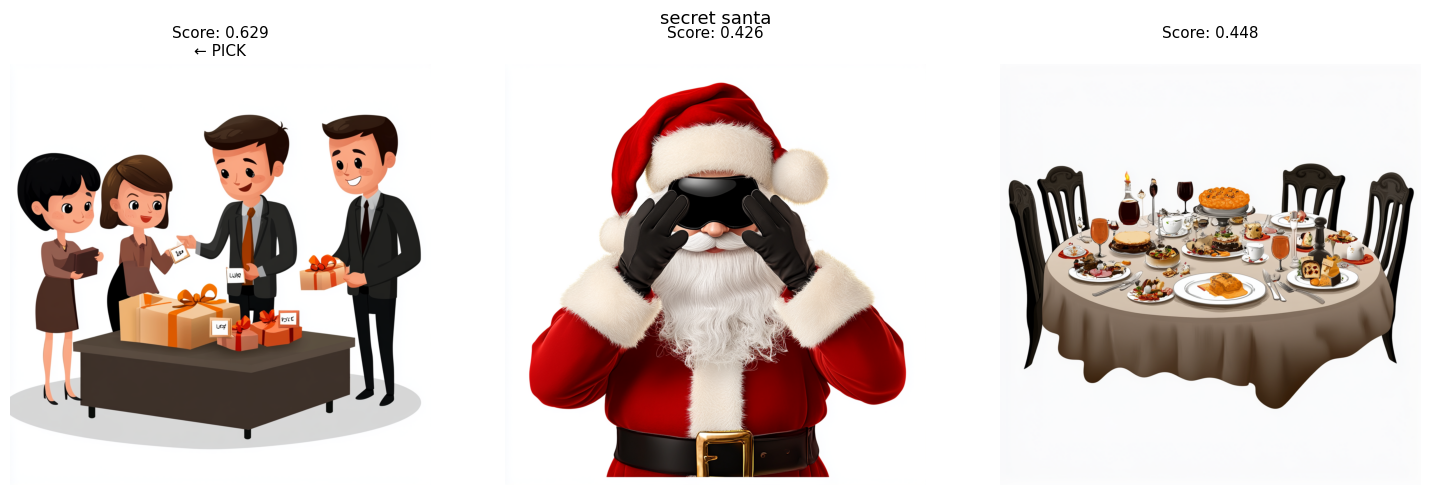

Correct


In [68]:
INPUT_SENTENCE = "She got very annoyed when some wag got her a puncture repair kit as a secret santa."

demo_group = test_df[test_df['sentence'].str.strip() == INPUT_SENTENCE.strip()].reset_index(drop=True)

feats, _ = extract_features(demo_group, test_img_path)
scores   = torch.sigmoid(model_2(torch.tensor(feats, dtype=torch.float32).to(device))).detach().cpu().numpy().flatten()

best = int(scores.argmax())
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i in range(len(demo_group)):
    axes[i].imshow(Image.open(os.path.join(test_img_path, demo_group['image_name'][i])))
    axes[i].axis('off')
    axes[i].set_title(f"Score: {scores[i]:.3f}\n{'← PICK' if i == best else ''}", fontsize=11)

plt.suptitle(demo_group['compound'][0], fontsize=13)
plt.tight_layout()
plt.show()

print("Correct" if best == list(demo_group['label']).index(1) else "Wrong")

##Step 5: Report. Please write down your report in another document (together with Task 1)
.